In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("german_credit_data.csv")

In [6]:
df.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,...,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker,target
0,< 0 DM,6,critical account/ other credits existing (not ...,radio/television,1169,unknown/ no savings account,>= 7 years,4,male : single,none,...,none,67,none,own,2,skilled employee/ official,1,"yes, registered under the customers name",yes,good
1,0 to < 200 DM,48,existing credits paid back duly till now,radio/television,5951,< 100 DM,1 to < 4 years,2,female : divorced/separated/married,none,...,none,22,none,own,1,skilled employee/ official,1,none,yes,bad
2,no checking account,12,critical account/ other credits existing (not ...,education,2096,< 100 DM,4 to < 7 years,2,male : single,none,...,none,49,none,own,1,unskilled - resident,2,none,yes,good
3,< 0 DM,42,existing credits paid back duly till now,furniture/equipment,7882,< 100 DM,4 to < 7 years,2,male : single,guarantor,...,car,45,none,for free,1,skilled employee/ official,2,none,yes,good
4,< 0 DM,24,delay in paying off in the past,car (new),4870,< 100 DM,1 to < 4 years,3,male : single,none,...,savings agreement/life insurance,53,none,for free,2,skilled employee/ official,2,none,yes,bad


In [7]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1000, 21)


In [8]:
df.columns


Index(['status_account', 'month_duration', 'credit_history', 'purpose',
       'credit_amount', 'status_savings', 'years_employment',
       'payment_to_income_ratio', 'status_and_sex', 'secondary_obligor',
       'residence_since', 'collateral', 'age', 'other_installment_plans',
       'housing', 'n_credits', 'job', 'n_guarantors', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [9]:
df.nunique()

,0
status_account,4
month_duration,33
credit_history,5
purpose,10
credit_amount,921
status_savings,5
years_employment,5
payment_to_income_ratio,4
status_and_sex,4
secondary_obligor,3


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   status_account           1000 non-null   object
 1   month_duration           1000 non-null   int64 
 2   credit_history           1000 non-null   object
 3   purpose                  1000 non-null   object
 4   credit_amount            1000 non-null   int64 
 5   status_savings           1000 non-null   object
 6   years_employment         1000 non-null   object
 7   payment_to_income_ratio  1000 non-null   int64 
 8   status_and_sex           1000 non-null   object
 9   secondary_obligor        1000 non-null   object
 10  residence_since          1000 non-null   int64 
 11  collateral               1000 non-null   object
 12  age                      1000 non-null   int64 
 13  other_installment_plans  1000 non-null   object
 14  housing                  1000 non-null   

In [11]:
df.isnull().sum()

,0
status_account,0
month_duration,0
credit_history,0
purpose,0
credit_amount,0
status_savings,0
years_employment,0
payment_to_income_ratio,0
status_and_sex,0
secondary_obligor,0


In [12]:
df.describe()

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000


In [13]:
df['target'].value_counts()

,count
target,
good,700
bad,300


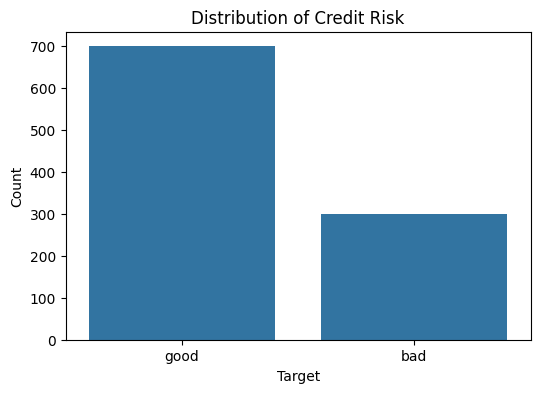

In [61]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)

plt.title("Distribution of Credit Risk")
plt.xlabel("Target")
plt.ylabel("Count")

plt.show()

**Distribution of Numerical Features**

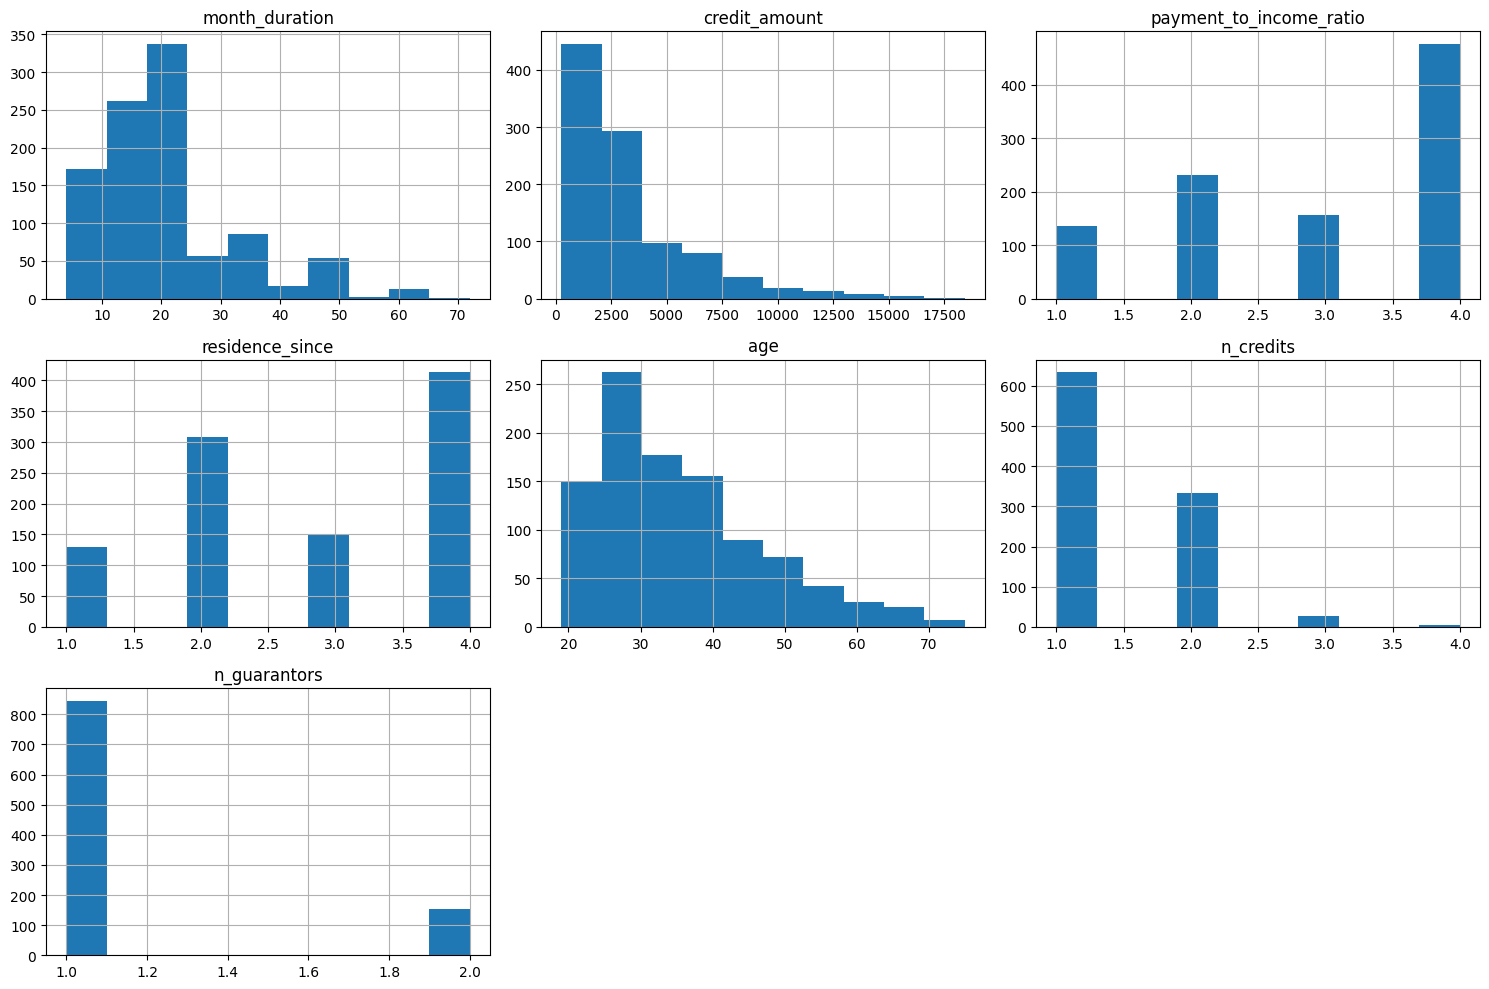

In [63]:
numerical_columns = df.select_dtypes(include=['int64']).columns

df[numerical_columns].hist(figsize=(15,10))

plt.tight_layout()

plt.show()

In [16]:
df.corr(numeric_only=True)

,month_duration,credit_amount,payment_to_income_ratio,residence_since,age,n_credits,n_guarantors
month_duration,1.000000,0.624984,0.074749,0.034067,-0.036136,-0.011284,-0.023834
credit_amount,0.624984,1.000000,-0.271316,0.028926,0.032716,0.020795,0.017142
payment_to_income_ratio,0.074749,-0.271316,1.000000,0.049302,0.058266,0.021669,-0.071207
residence_since,0.034067,0.028926,0.049302,1.000000,0.266419,0.089625,0.042643
age,-0.036136,0.032716,0.058266,0.266419,1.000000,0.149254,0.118201
n_credits,-0.011284,0.020795,0.021669,0.089625,0.149254,1.000000,0.109667
n_guarantors,-0.023834,0.017142,-0.071207,0.042643,0.118201,0.109667,1.000000


**Correlation Heatmap**


---



A correlation heatmap shows how numerical features are related to each other.

*   Correlation close to 1 means a strong positive relationship.

*   Correlation close to -1 means a strong negative relationship.


*   Correlation close to 0 means little or no linear relationship.








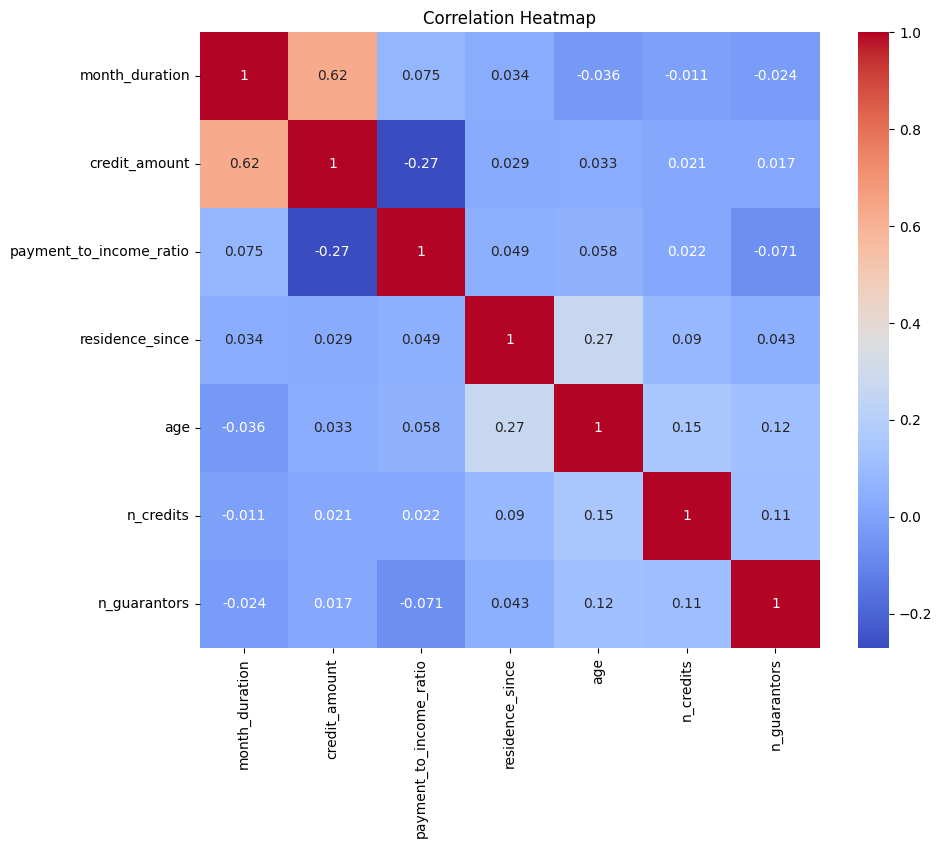

In [66]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [18]:
categorical_columns = df.select_dtypes(include=['object']).columns

categorical_columns

Index(['status_account', 'credit_history', 'purpose', 'status_savings',
       'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'is_foreign_worker', 'target'],
      dtype='object')

In [19]:
for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 status_account
status_account
no checking account    394
< 0 DM                 274
0 to < 200 DM          269
>= 200 DM               63
Name: count, dtype: int64

 credit_history
credit_history
existing credits paid back duly till now                       530
critical account/ other credits existing (not at this bank)    293
delay in paying off in the past                                 88
all credits at this bank paid back duly                         49
no credits taken/ all credits paid back duly                    40
Name: count, dtype: int64

 purpose
purpose
radio/television       280
car (new)              234
furniture/equipment    181
car (used)             103
business                97
education               50
repairs                 22
domestic appliances     12
others                  12
retraining               9
Name: count, dtype: int64

 status_savings
status_savings
< 100 DM                       603
unknown/ no savings account    183
100 to < 500 DM          

**Separate Features and Target**

In [20]:
# Features
X = df.drop('target', axis=1)

# Target
y = df['target']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 20)
Target Shape: (1000,)


In [21]:
X.dtypes

,0
status_account,object
month_duration,int64
credit_history,object
purpose,object
credit_amount,int64
status_savings,object
years_employment,object
payment_to_income_ratio,int64
status_and_sex,object
secondary_obligor,object


**Encode the Target Variable**



In [22]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

y = target_encoder.fit_transform(y)

print(y[:10])

[1 0 1 1 0 1 1 1 1 0]


**Encode Categorical Features And Verify the Encoding**

In [23]:
categorical_columns = X.select_dtypes(include='object').columns

print(categorical_columns)
from sklearn.preprocessing import LabelEncoder

label_encoders = {}

for column in categorical_columns:
    encoder = LabelEncoder()
    X[column] = encoder.fit_transform(X[column])
    label_encoders[column] = encoder

Index(['status_account', 'credit_history', 'purpose', 'status_savings',
       'years_employment', 'status_and_sex', 'secondary_obligor', 'collateral',
       'other_installment_plans', 'housing', 'job', 'telephone',
       'is_foreign_worker'],
      dtype='object')


In [24]:
X.head()

,status_account,month_duration,credit_history,purpose,credit_amount,status_savings,years_employment,payment_to_income_ratio,status_and_sex,secondary_obligor,residence_since,collateral,age,other_installment_plans,housing,n_credits,job,n_guarantors,telephone,is_foreign_worker
0,1,6,1,7,1169,4,3,4,3,2,4,1,67,1,1,2,1,1,1,1
1,0,48,3,7,5951,2,0,2,0,2,2,1,22,1,1,1,1,1,0,1
2,3,12,1,4,2096,2,1,2,3,2,3,1,49,1,1,1,3,2,0,1
3,1,42,3,5,7882,2,1,2,3,1,4,0,45,1,0,1,1,2,0,1
4,1,24,2,1,4870,2,0,3,3,2,4,3,53,1,0,2,1,2,0,1


In [25]:
X.dtypes

,0
status_account,int64
month_duration,int64
credit_history,int64
purpose,int64
credit_amount,int64
status_savings,int64
years_employment,int64
payment_to_income_ratio,int64
status_and_sex,int64
secondary_obligor,int64


# **Split the Dataset**

In [26]:
from sklearn.model_selection import train_test_split

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (800, 20)
Testing Features  : (200, 20)
Training Labels   : (800,)
Testing Labels    : (200,)


**Apply StandardScaler**

In [27]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Scale training data
X_train_scaled = scaler.fit_transform(X_train)

# Scale testing data
X_test_scaled = scaler.transform(X_test)

**Import Logistic Regression And Creating the Model**

In [28]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(random_state=42)

In [29]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [30]:
y_pred = log_model.predict(X_test_scaled)

In [31]:
print("Actual Values     :", y_test[:10])
print("Predicted Values  :", y_pred[:10])

Actual Values     : [0 1 1 1 1 1 1 1 1 1]
Predicted Values  : [1 1 1 1 1 1 1 1 1 1]


In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2f}")

Accuracy : 0.72


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.55      0.29      0.38        59
           1       0.75      0.90      0.82       141

    accuracy                           0.72       200
   macro avg       0.65      0.59      0.60       200
weighted avg       0.69      0.72      0.69       200



In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 17  42]
 [ 14 127]]


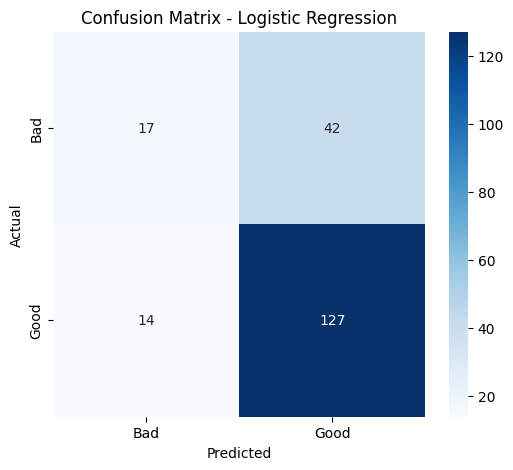

In [35]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [36]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [37]:
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)
print("Actual Values     :", y_test[:10])
print("Predicted Values  :", y_pred_dt[:10])

Actual Values     : [0 1 1 1 1 1 1 1 1 1]
Predicted Values  : [1 1 1 1 1 1 1 1 1 1]


In [38]:
from sklearn.metrics import accuracy_score

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")

Decision Tree Accuracy: 0.71


In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.51      0.44      0.47        59
           1       0.78      0.82      0.80       141

    accuracy                           0.71       200
   macro avg       0.64      0.63      0.64       200
weighted avg       0.70      0.71      0.70       200



In [40]:
from sklearn.metrics import confusion_matrix

dt_cm = confusion_matrix(y_test, y_pred_dt)

print(dt_cm)

[[ 26  33]
 [ 25 116]]


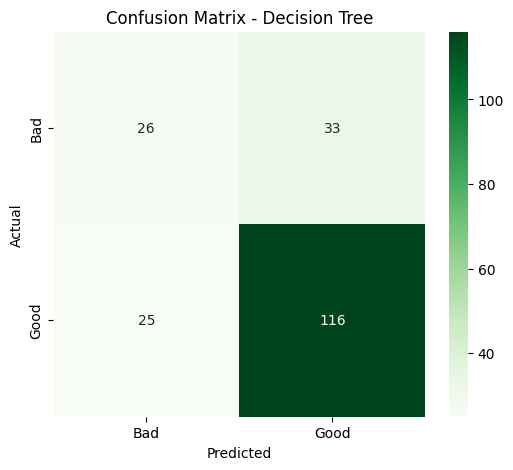

In [41]:
plt.figure(figsize=(6,5))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [42]:
comparison = {
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [accuracy, dt_accuracy]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy
0,Logistic Regression,0.72
1,Decision Tree,0.71


In [43]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [44]:
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print("Actual Values     :", y_test[:10])
print("Predicted Values  :", y_pred_rf[:10])

Actual Values     : [0 1 1 1 1 1 1 1 1 1]
Predicted Values  : [1 1 0 1 1 1 1 1 1 1]


In [45]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy:.2f}")

Random Forest Accuracy: 0.79


In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.74      0.42      0.54        59
           1       0.80      0.94      0.86       141

    accuracy                           0.79       200
   macro avg       0.77      0.68      0.70       200
weighted avg       0.78      0.79      0.76       200



In [47]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, y_pred_rf)

print(rf_cm)

[[ 25  34]
 [  9 132]]


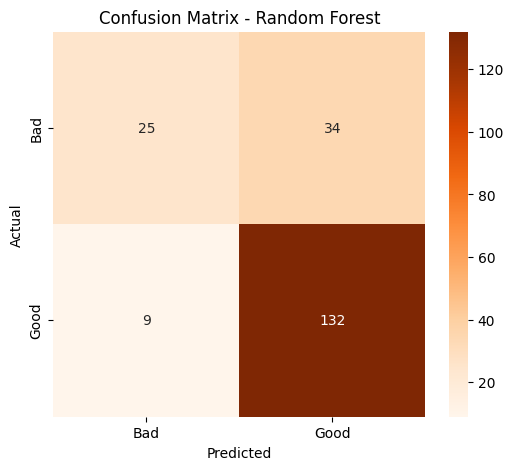

In [48]:
plt.figure(figsize=(6,5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Oranges',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

In [49]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.720
1,Decision Tree,0.710
2,Random Forest,0.785


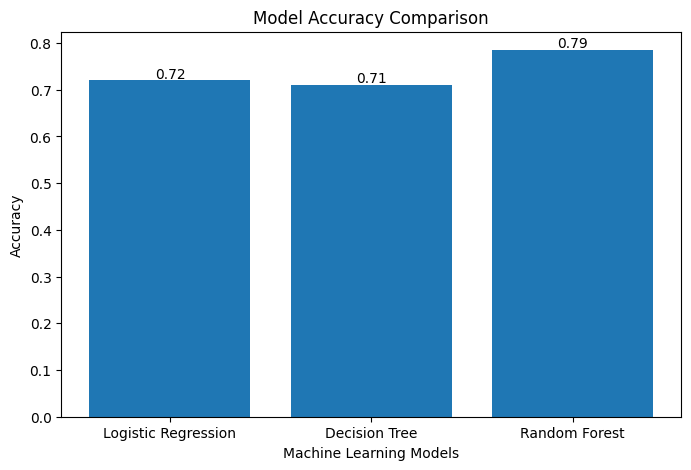

In [50]:
plt.figure(figsize=(8,5))

plt.bar(comparison["Model"], comparison["Accuracy"])

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy")

for i, value in enumerate(comparison["Accuracy"]):
    plt.text(i, value + 0.005, f"{value:.2f}", ha="center")

plt.show()

In [51]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,credit_amount,0.132465
12,age,0.108433
0,status_account,0.107271
1,month_duration,0.094339
3,purpose,0.069329
2,credit_history,0.059104
6,years_employment,0.050732
11,collateral,0.048576
5,status_savings,0.044027
7,payment_to_income_ratio,0.042691


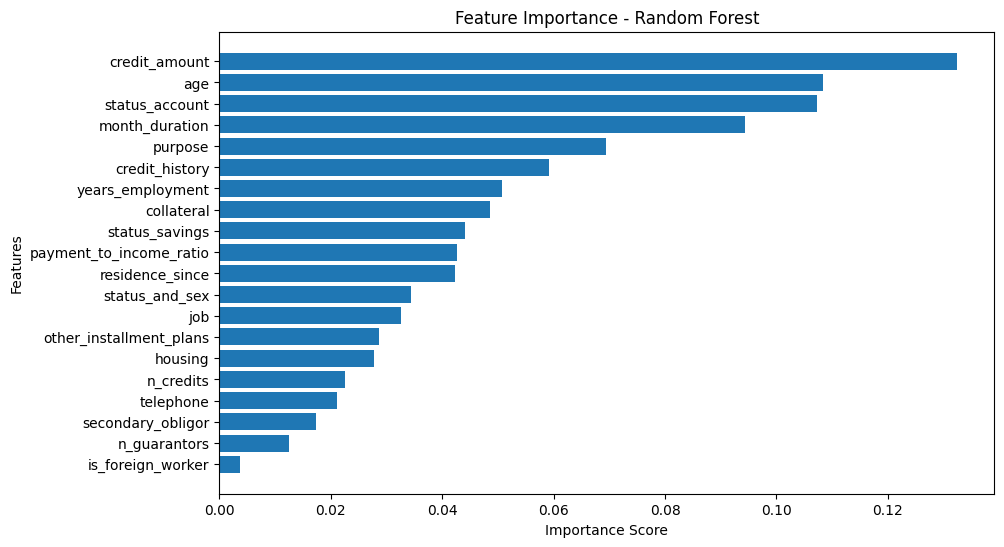

In [52]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.gca().invert_yaxis()

plt.show()

In [53]:
from sklearn.ensemble import RandomForestClassifier
rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)
rf_balanced.fit(X_train, y_train)
y_pred_balanced = rf_balanced.predict(X_test)

In [54]:
from sklearn.metrics import accuracy_score

balanced_accuracy = accuracy_score(y_test, y_pred_balanced)

print(f"Balanced Random Forest Accuracy: {balanced_accuracy:.2f}")

Balanced Random Forest Accuracy: 0.74


In [55]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.64      0.31      0.41        59
           1       0.76      0.93      0.84       141

    accuracy                           0.74       200
   macro avg       0.70      0.62      0.63       200
weighted avg       0.73      0.74      0.71       200



In [56]:
from sklearn.metrics import confusion_matrix

balanced_cm = confusion_matrix(y_test, y_pred_balanced)

print(balanced_cm)

[[ 18  41]
 [ 10 131]]


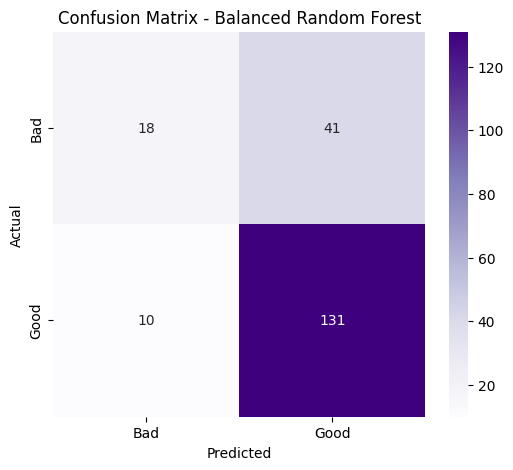

In [57]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    balanced_cm,
    annot=True,
    fmt='d',
    cmap='Purples',
    xticklabels=['Bad', 'Good'],
    yticklabels=['Bad', 'Good']
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Balanced Random Forest")

plt.show()

In [58]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Balanced Random Forest"
    ],
    "Accuracy": [
        accuracy,
        dt_accuracy,
        rf_accuracy,
        balanced_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.720
1,Decision Tree,0.710
2,Random Forest,0.785
3,Balanced Random Forest,0.745


In [68]:
import joblib